# 2AMU20 Generative AI Models: Homework Assignment 3
## Variational Autoencoders (VAE)

**Group:** _Student 1 (id), Student 2 (id), Student 3 (id)_

_Notebook structured task-by-task. Each section is self-contained and reuses the shared building blocks defined in the **Setup**._

---
# Setup
Drive mount, imports, global configuration (paths / device / reproducibility).

### Mount Google Drive
Checkpoints and figures are persisted under `MyDrive/GenAI Homeworks/Assignment 3`.

In [2]:
# Mount Drive (Colab). Set RUN_ON_COLAB = False to run locally.
RUN_ON_COLAB = True

if RUN_ON_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

Mounted at /content/drive


### Imports

In [3]:
import os
import time
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import datasets, transforms
from torchvision.utils import make_grid

### Global configuration
Paths, compute device and random seed. Change `PROJECT_DIR` here only.

In [54]:
# ---- Paths ----
if RUN_ON_COLAB:
    PROJECT_DIR = Path('/content/drive/MyDrive/GenAI Homeworks/Assignment 3')
else:
    PROJECT_DIR = Path('./Assignment3_artifacts')

DATA_DIR = PROJECT_DIR / 'data'        # MNIST download cache
CKPT_DIR = PROJECT_DIR / 'checkpoints' # saved model weights
FIG_DIR  = PROJECT_DIR / 'figures'     # exported plots for the report

for d in (DATA_DIR, CKPT_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ---- Device ----
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---- Reproducibility ----
SEED = 42

def set_seed(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

print(f'Project dir : {PROJECT_DIR}')
print(f'Device      : {DEVICE}')
print(f'Torch       : {torch.__version__}')

Project dir : /content/drive/MyDrive/GenAI Homeworks/Assignment 3
Device      : cuda
Torch       : 2.11.0+cu128


---
# Task 1: Implement and Train a VAE
Convolutional VAE with $K$-dimensional latent space and Gaussian $p(\mathbf{X}\mid\mathbf{z})$ with independent components.

## Data: MNIST
Load MNIST, normalise to $[0,1]$, split train (50k) / validation (10k) / test (10k).

In [19]:
# ---- Data hyperparameters ----
BATCH_SIZE = 128

# ToTensor() maps a PIL uint8 image in [0, 255] to a float32 tensor in [0, 1],
# which is exactly the normalisation required by the assignment (divide by 255).
transform = transforms.ToTensor()

# MNIST is downloaded once into DATA_DIR (on Drive) and then cached; torchvision
# loads the whole dataset into memory, so training batches are read from RAM.
train_full = datasets.MNIST(root=str(DATA_DIR), train=True,  download=True, transform=transform)
test_set   = datasets.MNIST(root=str(DATA_DIR), train=False, download=True, transform=transform)

# Sanity checks required by Task 1.
assert len(train_full) == 60_000, f'expected 60000 train images, got {len(train_full)}'
assert len(test_set)   == 10_000, f'expected 10000 test images, got {len(test_set)}'

# Verify image shape and that pixel values lie in [0, 1].
_x0, _y0 = train_full[0]
print(f'Train images : {len(train_full)}')
print(f'Test images  : {len(test_set)}')
print(f'Image shape  : {tuple(_x0.shape)}  (C, H, W)')
print(f'Pixel range  : [{_x0.min():.3f}, {_x0.max():.3f}]')

Train images : 60000
Test images  : 10000
Image shape  : (1, 28, 28)  (C, H, W)
Pixel range  : [0.000, 1.000]


In [20]:
# Deterministic split required by the assignment:
# first 50,000 images -> training, last 10,000 images -> validation.
train_set = Subset(train_full, range(0, 50_000))
val_set   = Subset(train_full, range(50_000, 60_000))

# pin_memory speeds up host->GPU transfer; num_workers parallelises batch loading.
_loader_kwargs = dict(num_workers=2, pin_memory=(DEVICE.type == 'cuda'))
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  **_loader_kwargs)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, **_loader_kwargs)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, **_loader_kwargs)

print(f'Train / Val / Test : {len(train_set)} / {len(val_set)} / {len(test_set)}')

Train / Val / Test : 50000 / 10000 / 10000


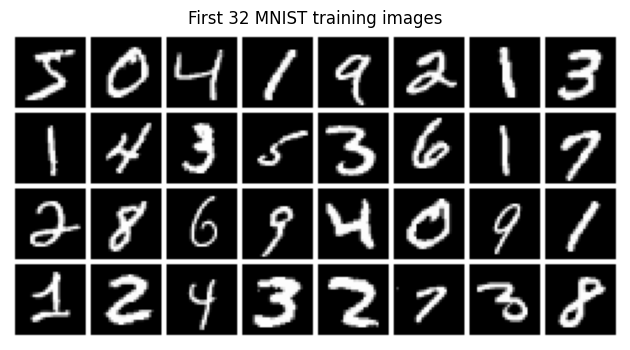

In [21]:
# Quick visual sanity check: first 32 training images in an 8x4 grid.
_imgs = torch.stack([train_set[i][0] for i in range(32)])
_grid = make_grid(_imgs, nrow=8, pad_value=1.0)
plt.figure(figsize=(8, 4))
plt.imshow(_grid.permute(1, 2, 0).squeeze().numpy(), cmap='gray')
plt.axis('off')
plt.title('First 32 MNIST training images')
plt.show()

## Task 1a: Model Setup
Encoder / decoder architecture, library and optimisation routine.

**Model setup (Task 1a).** The model is implemented in **PyTorch**.

**Encoder $q(\mathbf{z}\mid\mathbf{x})$ (convolutional).** Two stride-2 convolutions reduce the $28\times28$ image to a $7\times7$ feature map: $\text{Conv}(1\to32)\to\text{ReLU}\to\text{Conv}(32\to64)\to\text{ReLU}$ (each $4\times4$ kernel, stride 2, padding 1, so $28\to14\to7$). The resulting $64\cdot7\cdot7$ features are flattened and fed to two linear heads that output the mean $\boldsymbol{\mu}_z$ and log-variance $\log\boldsymbol{\sigma}_z^2$ of the diagonal Gaussian posterior over the $K=16$ latent dimensions.

**Decoder $p(\mathbf{x}\mid\mathbf{z})$ (deconvolutional).** A linear layer maps $\mathbf{z}\in\mathbb{R}^{K}$ to a $64\cdot7\cdot7$ tensor reshaped to $(64,7,7)$, followed by two stride-2 transposed convolutions that upsample back to $28\times28$: $\text{ConvT}(64\to32)\to\text{ReLU}\to\text{ConvT}(32\to16)\to\text{ReLU}$ ($7\to14\to28$). On top of this shared trunk sit **two $3\times3$ convolutional heads**: one produces the per-pixel mean $\boldsymbol{\mu}(\mathbf{z})$ (through a sigmoid, so $\mu_d(\mathbf{z})\in[0,1]$, matching the data range), the other the per-pixel log-variance $\log\boldsymbol{\sigma}^2(\mathbf{z})$. The trunk is deliberately separated from the head so that Task 2 (Beta / Categorical / Bernoulli) can reuse the same encoder and decoder backbone and only swap the final head.

**Latent space.** $\mathcal{Z}=\mathbb{R}^{K}$ with $K=16>1$; the prior is the standard Gaussian $p(\mathbf{z})=\mathcal{N}(\mathbf{0},\mathbf{I})$.

**Optimisation routine.** We maximise the (1-sample Monte-Carlo) ELBO with **Adam**, using a batch size of **128** and the reparameterisation trick. Regarding hyperparameters *that differ from the framework defaults*: Adam is run with learning rate `1e-3`, which is in fact PyTorch's default, so the optimiser uses default settings; the deliberate, non-default choices are the **batch size (128)** and, for numerical stability of the Gaussian decoder, **clamping the predicted log-variance to $[-6, 2]$** so that $\sigma^2(\mathbf{z})$ can neither collapse to $0$ nor explode. Training length is governed by the early-stopping criterion of Task 1c (`max_epochs = 50`, `patience = 5`).

In [22]:
# ---- Model & training hyperparameters (Task 1) ----
K = 16                 # latent space dimension (Z = R^K), with K > 1

# Adam optimiser settings (Task 1a)
LR = 1e-3

# Training loop / stopping criterion (Task 1c)
MAX_EPOCHS = 50        # hard cap on the number of epochs
PATIENCE   = 5         # early-stopping patience on the validation ELBO

# Numerical stability for the Gaussian decoder: clamp the predicted
# log-variance so that sigma^2(z) cannot collapse to 0 or explode.
LOGVAR_MIN, LOGVAR_MAX = -6.0, 2.0

In [23]:
class Encoder(nn.Module):
    """Convolutional encoder q(z|x): outputs the mean and log-variance of a
    diagonal Gaussian over the K-dimensional latent space."""
    def __init__(self, k=K):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),   # 28 -> 14
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 14 -> 7
            nn.ReLU(inplace=True),
        )
        self.fc_mu     = nn.Linear(64 * 7 * 7, k)
        self.fc_logvar = nn.Linear(64 * 7 * 7, k)

    def forward(self, x):
        h = self.conv(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)


class DecoderBackbone(nn.Module):
    """Shared deconvolutional trunk: maps z to a (16, 28, 28) feature map.
    The distribution-specific head is attached on top (Gaussian here;
    Beta / Categorical / Bernoulli in Task 2 reuse this same backbone)."""
    def __init__(self, k=K):
        super().__init__()
        self.fc = nn.Linear(k, 64 * 7 * 7)
        self.deconv = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 7 -> 14
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),  # 14 -> 28
            nn.ReLU(inplace=True),
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 64, 7, 7)
        return self.deconv(h)  # (B, 16, 28, 28)


class GaussianVAE(nn.Module):
    """VAE with a Gaussian p(x|z) with independent components (Task 1).
    Per pixel, the decoder outputs a mean mu(z) in [0,1] (via sigmoid) and a
    log-variance log sigma^2(z) (clamped for numerical stability)."""
    def __init__(self, k=K):
        super().__init__()
        self.encoder     = Encoder(k)
        self.backbone    = DecoderBackbone(k)
        self.mu_head     = nn.Conv2d(16, 1, kernel_size=3, padding=1)
        self.logvar_head = nn.Conv2d(16, 1, kernel_size=3, padding=1)

    def encode(self, x):
        return self.encoder(x)  # mu_z, logvar_z

    def reparameterize(self, mu, logvar):
        # z = mu + sigma * eps,  eps ~ N(0, I)   (reparameterisation trick)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.backbone(z)
        mu_x     = torch.sigmoid(self.mu_head(h))                 # pixel mean in [0,1]
        logvar_x = self.logvar_head(h).clamp(LOGVAR_MIN, LOGVAR_MAX)
        return mu_x, logvar_x

    def forward(self, x):
        mu_z, logvar_z = self.encode(x)
        z = self.reparameterize(mu_z, logvar_z)
        mu_x, logvar_x = self.decode(z)
        return mu_x, logvar_x, mu_z, logvar_z, z


# Quick shape sanity check (CPU, no training).
_m = GaussianVAE()
_n_params = sum(p.numel() for p in _m.parameters())
_dummy = torch.zeros(4, 1, 28, 28)
_mu_x, _lv_x, _mu_z, _lv_z, _z = _m(_dummy)
print(f'Parameters         : {_n_params:,}')
print(f'mu_x / logvar_x    : {tuple(_mu_x.shape)} / {tuple(_lv_x.shape)}')
print(f'mu_z / logvar_z    : {tuple(_mu_z.shape)} / {tuple(_lv_z.shape)}')
print(f'z                  : {tuple(_z.shape)}')
del _m, _dummy, _mu_x, _lv_x, _mu_z, _lv_z, _z

Parameters         : 228,370
mu_x / logvar_x    : (4, 1, 28, 28) / (4, 1, 28, 28)
mu_z / logvar_z    : (4, 16) / (4, 16)
z                  : (4, 16)


## Task 1b: Model Training
Explicit $\log p(\mathbf{x}\mid\mathbf{z})$, ELBO training, train/validation ELBO curves.

**Conditional log-likelihood (Task 1b).** With a Gaussian $p(\mathbf{x}\mid\mathbf{z})$ with independent components, for a single datapoint $\mathbf{x}=(x_1,\dots,x_D)$:

$$
\log p(\mathbf{x}\mid\mathbf{z}) \;=\; \sum_{d=1}^{D} \log \mathcal{N}\!\big(x_d \,\big|\, \mu_d(\mathbf{z}),\, \sigma_d^2(\mathbf{z})\big)
\;=\; \sum_{d=1}^{D} \left[ -\tfrac{1}{2}\log(2\pi) \;-\; \tfrac{1}{2}\log \sigma_d^2(\mathbf{z}) \;-\; \frac{\big(x_d - \mu_d(\mathbf{z})\big)^2}{2\,\sigma_d^2(\mathbf{z})} \right].
$$

The KL term has a closed form for a diagonal Gaussian $q(\mathbf{z}\mid\mathbf{x})=\mathcal{N}(\boldsymbol{\mu}_z,\operatorname{diag}\boldsymbol{\sigma}_z^2)$ against the prior $p(\mathbf{z})=\mathcal{N}(\mathbf{0},\mathbf{I})$:

$$
\mathrm{KL}\big(q(\mathbf{z}\mid\mathbf{x})\,\|\,p(\mathbf{z})\big) \;=\; -\tfrac{1}{2}\sum_{k=1}^{K}\Big(1 + \log\sigma_{z,k}^2 - \mu_{z,k}^2 - \sigma_{z,k}^2\Big).
$$

The training objective is the ELBO $\;\mathcal{L}(\mathbf{x}) = \mathbb{E}_{q(\mathbf{z}\mid\mathbf{x})}\!\big[\log p(\mathbf{x}\mid\mathbf{z})\big] - \mathrm{KL}\big(q(\mathbf{z}\mid\mathbf{x})\,\|\,p(\mathbf{z})\big)$, estimated with a single Monte-Carlo sample of $\mathbf{z}$ via the reparameterisation trick. We maximise the ELBO (equivalently, minimise $-\mathcal{L}$).

In [24]:
LOG2PI = math.log(2.0 * math.pi)


def gaussian_log_likelihood(x, mu_x, logvar_x):
    """log p(x|z) for a Gaussian decoder with independent components.

    Returns a per-sample tensor of shape (B,): the sum over the D pixels of
    the per-pixel Gaussian log-density.
    """
    # per-pixel log N(x_d | mu_d, sigma_d^2)
    ll = -0.5 * (LOG2PI + logvar_x + (x - mu_x) ** 2 / torch.exp(logvar_x))
    return ll.flatten(1).sum(dim=1)  # sum over pixels -> (B,)


def kl_standard_normal(mu_z, logvar_z):
    """KL( q(z|x) || N(0, I) ) in closed form. Returns shape (B,)."""
    return -0.5 * (1.0 + logvar_z - mu_z.pow(2) - logvar_z.exp()).sum(dim=1)


def elbo_terms(x, model_out):
    """Per-sample reconstruction log-likelihood, KL, and ELBO.

    model_out is the tuple returned by GaussianVAE.forward:
    (mu_x, logvar_x, mu_z, logvar_z, z).
    """
    mu_x, logvar_x, mu_z, logvar_z, _z = model_out
    log_px_z = gaussian_log_likelihood(x, mu_x, logvar_x)  # (B,)
    kl       = kl_standard_normal(mu_z, logvar_z)           # (B,)
    return log_px_z, kl, log_px_z - kl                      # recon, kl, elbo

In [25]:
@torch.no_grad()
def evaluate_elbo(model, loader,elbo_terms =elbo_terms):
    """Mean ELBO over a loader, with gradient tracking disabled (validation)."""
    model.eval()
    total, n = 0.0, 0
    for x, _ in loader:
        x = x.to(DEVICE)
        _, _, elbo = elbo_terms(x, model(x))
        total += elbo.sum().item()
        n += x.size(0)
    return total / n


def train_one_epoch(model, loader, optimizer,elbo_terms =elbo_terms):
    """Single training pass; returns the mean ELBO over the epoch."""
    model.train()
    total, n = 0.0, 0
    for x, _ in loader:
        x = x.to(DEVICE)
        optimizer.zero_grad()
        _, _, elbo = elbo_terms(x, model(x))
        loss = -elbo.mean()        # maximise ELBO == minimise negative ELBO
        loss.backward()
        optimizer.step()
        total += elbo.sum().item()
        n += x.size(0)
    return total / n

In [48]:
def save_checkpoint(model, optimizer, history, path):
    """Persist model + optimiser state and the training history."""
    torch.save({'model': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'history': history}, path)


def load_checkpoint(model, path, optimizer=None, map_location=DEVICE):
    """Restore weights (and optionally optimiser state); returns history."""
    ckpt = torch.load(path, map_location=map_location)
    model.load_state_dict(ckpt['model'])
    if optimizer is not None and 'optimizer' in ckpt:
        optimizer.load_state_dict(ckpt['optimizer'])
    return ckpt.get('history', None)


def fit(model, train_loader, val_loader, optimizer, ckpt_path,
        max_epochs=MAX_EPOCHS, patience=PATIENCE, verbose=True, elbo_terms=elbo_terms):
    """Train by maximising the ELBO, with early stopping on the validation ELBO.

    Stopping criterion (Task 1c): after each epoch we evaluate the mean ELBO on
    the validation set. We keep the model with the best validation ELBO seen so
    far; if it does not improve for `patience` consecutive epochs we stop early.
    The best model (not the last) is saved to and reloaded from `ckpt_path`.
    Returns a history dict with per-epoch train/validation ELBO.
    """
    history = {'train_elbo': [], 'val_elbo': []}
    best_val, best_epoch, epochs_no_improve = -float('inf'), -1, 0

    for epoch in range(1, max_epochs + 1):
        tr = train_one_epoch(model, train_loader, optimizer,elbo_terms)
        va = evaluate_elbo(model, val_loader,elbo_terms)
        history['train_elbo'].append(tr)
        history['val_elbo'].append(va)

        if va > best_val:
            best_val, best_epoch, epochs_no_improve = va, epoch, 0
            save_checkpoint(model, optimizer, history, ckpt_path)
            flag = '  <- best (saved)'
        else:
            epochs_no_improve += 1
            flag = ''
        if verbose:
            print(f'Epoch {epoch:2d} | train ELBO {tr:9.2f} | val ELBO {va:9.2f}{flag}')

        if epochs_no_improve >= patience:
            if verbose:
                print(f'Early stopping at epoch {epoch} '
                      f'(best val ELBO {best_val:.2f} at epoch {best_epoch}).')
            break

    # restore the best model before returning
    load_checkpoint(model, ckpt_path, optimizer)
    history['best_epoch'] = best_epoch
    history['best_val_elbo'] = best_val
    return history

In [32]:
# Instantiate, train (or reload an existing checkpoint).
set_seed()
vae = GaussianVAE(K).to(DEVICE)
optimizer = torch.optim.Adam(vae.parameters(), lr=LR)

CKPT_PATH = CKPT_DIR / 'vae_gaussian.pt'
RETRAIN = True  # set False to skip training and load the saved checkpoint

if RETRAIN or not CKPT_PATH.exists():
    history = fit(vae, train_loader, val_loader, optimizer, CKPT_PATH)
else:
    history = load_checkpoint(vae, CKPT_PATH, optimizer)
    print(f'Loaded checkpoint from {CKPT_PATH}')

print(f"Best val ELBO {history['best_val_elbo']:.2f} at epoch {history['best_epoch']}")

Epoch  1 | train ELBO    791.23 | val ELBO   1121.44  <- best (saved)
Epoch  2 | train ELBO   1171.12 | val ELBO   1203.80  <- best (saved)
Epoch  3 | train ELBO   1221.54 | val ELBO   1232.29  <- best (saved)
Epoch  4 | train ELBO   1244.84 | val ELBO   1242.89  <- best (saved)
Epoch  5 | train ELBO   1259.41 | val ELBO   1259.77  <- best (saved)
Epoch  6 | train ELBO   1269.49 | val ELBO   1266.84  <- best (saved)
Epoch  7 | train ELBO   1277.38 | val ELBO   1273.10  <- best (saved)
Epoch  8 | train ELBO   1284.00 | val ELBO   1278.66  <- best (saved)
Epoch  9 | train ELBO   1289.27 | val ELBO   1282.19  <- best (saved)
Epoch 10 | train ELBO   1293.18 | val ELBO   1286.24  <- best (saved)
Epoch 11 | train ELBO   1297.08 | val ELBO   1288.27  <- best (saved)
Epoch 12 | train ELBO   1300.15 | val ELBO   1289.31  <- best (saved)
Epoch 13 | train ELBO   1302.75 | val ELBO   1291.44  <- best (saved)
Epoch 14 | train ELBO   1305.26 | val ELBO   1293.40  <- best (saved)
Epoch 15 | train ELB

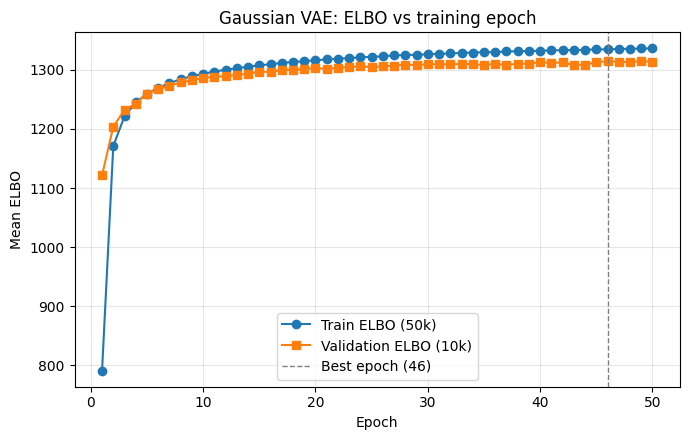

In [33]:
# ELBO curves: training (50k) vs validation (10k), per epoch (Task 1b).
epochs = range(1, len(history['train_elbo']) + 1)
plt.figure(figsize=(7, 4.5))
plt.plot(epochs, history['train_elbo'], marker='o', label='Train ELBO (50k)')
plt.plot(epochs, history['val_elbo'],   marker='s', label='Validation ELBO (10k)')
plt.axvline(history['best_epoch'], color='gray', ls='--', lw=1,
            label=f"Best epoch ({history['best_epoch']})")
plt.xlabel('Epoch')
plt.ylabel('Mean ELBO')
plt.title('Gaussian VAE: ELBO vs training epoch')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'task1b_elbo_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 1c: Stopping Criterion
Early stopping on validation ELBO + checkpoint save/load.

**Stopping criterion (Task 1c).** We train by *maximising* the ELBO. The ELBO measured on the **training** set tends to increase essentially monotonically, because the optimiser keeps fitting the 50k training images more and more closely; on its own it therefore never tells us when to stop. What we actually care about is **generalisation**, so we monitor the ELBO on the **validation** set (the 10k images that are never used to update the weights).

The validation ELBO typically *rises*, then *plateaus*, and eventually may *decrease*: that downturn is the signature of **overfitting**, the point at which the model starts capturing peculiarities of the training images rather than structure that transfers to unseen data.

Concretely, the criterion implemented in `fit` is **early stopping on the validation ELBO**:

- after every epoch we compute the mean validation ELBO under `torch.no_grad()`, so this evaluation never contributes gradients to training (an explicit requirement of the assignment);
- we track the best validation ELBO seen so far and **checkpoint that model** to Drive;
- if the validation ELBO does not improve for `patience = 5` consecutive epochs, we stop;
- a hard cap `max_epochs = 50` acts as a safety net in case the validation ELBO keeps creeping up;
- finally we **reload the best model** (not the last one), so the model we keep is the one that generalised best.

Saving/loading the checkpoint (as suggested in the assignment hint) also means we can reuse the trained model without re-training.

In [34]:
# Summary of the stopping criterion outcome (read-only; reuses `history` from fit).
n_epochs   = len(history["train_elbo"])
best_epoch = history["best_epoch"]
stopped_early = n_epochs < MAX_EPOCHS

print(f"Epochs run            : {n_epochs} (max_epochs = {MAX_EPOCHS}, patience = {PATIENCE})")
print(f"Best epoch            : {best_epoch}")
print(f"Best validation ELBO  : {history['best_val_elbo']:.2f}")
print(f"Train ELBO @ best      : {history['train_elbo'][best_epoch - 1]:.2f}")
print(f"Stopped early?        : {stopped_early}")
print(f"Best model checkpoint : {CKPT_PATH}  (exists: {CKPT_PATH.exists()})")

Epochs run            : 50 (max_epochs = 50, patience = 5)
Best epoch            : 46
Best validation ELBO  : 1314.51
Train ELBO @ best      : 1334.63
Stopped early?        : False
Best model checkpoint : /content/drive/MyDrive/GenAI Homeworks/Assignment 3/checkpoints/vae_gaussian.pt  (exists: True)


## Task 1d: Model Testing
Reconstructions of the first 32 test images (8x8 grid) and new samples from the prior.

**Reconstruction and sampling recipe (Task 1d).** Following the assignment, a reconstruction of a test image $\mathbf{x}$ is obtained by: (1) encoding $\mathbf{x}$ to get $q(\mathbf{z}\mid\mathbf{x})=\mathcal{N}(\boldsymbol{\mu}_z,\operatorname{diag}\boldsymbol{\sigma}_z^2)$; (2) drawing $\mathbf{z}\sim q(\mathbf{z}\mid\mathbf{x})$; (3) decoding $\mathbf{z}$ into $p(\mathbf{x}\mid\mathbf{z})=\mathcal{N}(\boldsymbol{\mu}(\mathbf{z}),\operatorname{diag}\boldsymbol{\sigma}^2(\mathbf{z}))$; (4) sampling $\mathbf{x}'\sim p(\mathbf{x}\mid\mathbf{z})$. New samples are generated the same way but with $\mathbf{z}\sim p(\mathbf{z})=\mathcal{N}(\mathbf{0},\mathbf{I})$ drawn from the prior. Sampled images are clipped to $[0,1]$ for display.

In [35]:
# Test-set ELBO with reconstruction / KL decomposition.
# A sanity signal that the model generalises and does not suffer posterior
# collapse (KL ~ 0 would mean the latent z is ignored).
@torch.no_grad()
def evaluate_elbo_decomposed(model, loader):
    model.eval()
    tot_recon, tot_kl, n = 0.0, 0.0, 0
    for x, _ in loader:
        x = x.to(DEVICE)
        recon, kl, _ = elbo_terms(x, model(x))
        tot_recon += recon.sum().item()
        tot_kl    += kl.sum().item()
        n += x.size(0)
    recon, kl = tot_recon / n, tot_kl / n
    return recon, kl, recon - kl  # mean recon log-lik, mean KL, mean ELBO

te_recon, te_kl, te_elbo = evaluate_elbo_decomposed(vae, test_loader)
print(f'Test set (10k):  ELBO {te_elbo:9.2f}  =  recon {te_recon:9.2f}  -  KL {te_kl:7.2f}')

Test set (10k):  ELBO   1317.98  =  recon   1364.85  -  KL   46.87


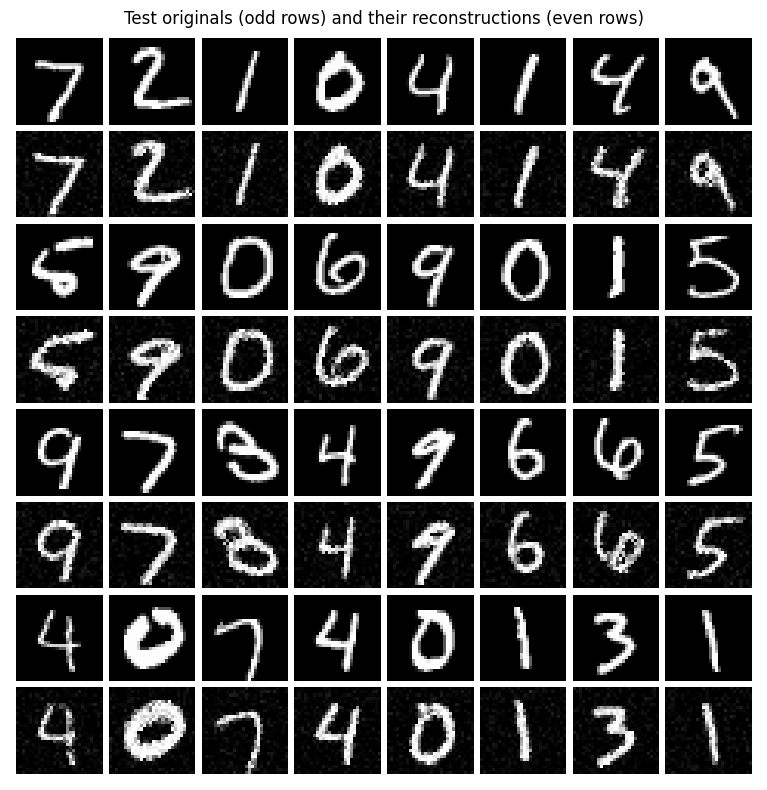

In [36]:
# Task 1d: reconstruct the first 32 test images and show them next to the originals.
@torch.no_grad()
def reconstruct(model, x):
    """Encoder -> sample z ~ q(z|x) -> decoder -> sample x' ~ p(x|z)."""
    model.eval()
    mu_z, logvar_z = model.encode(x)
    z = model.reparameterize(mu_z, logvar_z)
    mu_x, logvar_x = model.decode(z)
    x_sample = mu_x + torch.exp(0.5 * logvar_x) * torch.randn_like(mu_x)
    return x_sample.clamp(0.0, 1.0)

# First 32 test images.
x_test = torch.stack([test_set[i][0] for i in range(32)]).to(DEVICE)
x_rec  = reconstruct(vae, x_test)

# Build an 8x8 grid where each block of 2 rows is [originals row, reconstructions row].
orig = x_test.cpu().view(4, 8, 1, 28, 28)
rec  = x_rec.cpu().view(4, 8, 1, 28, 28)
rows = torch.cat([orig, rec], dim=1).view(64, 1, 28, 28)  # 4*(8 orig + 8 rec)
grid = make_grid(rows, nrow=8, pad_value=1.0)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).squeeze().numpy(), cmap='gray')
plt.axis('off')
plt.title('Test originals (odd rows) and their reconstructions (even rows)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'task1d_reconstructions.png', dpi=150, bbox_inches='tight')
plt.show()

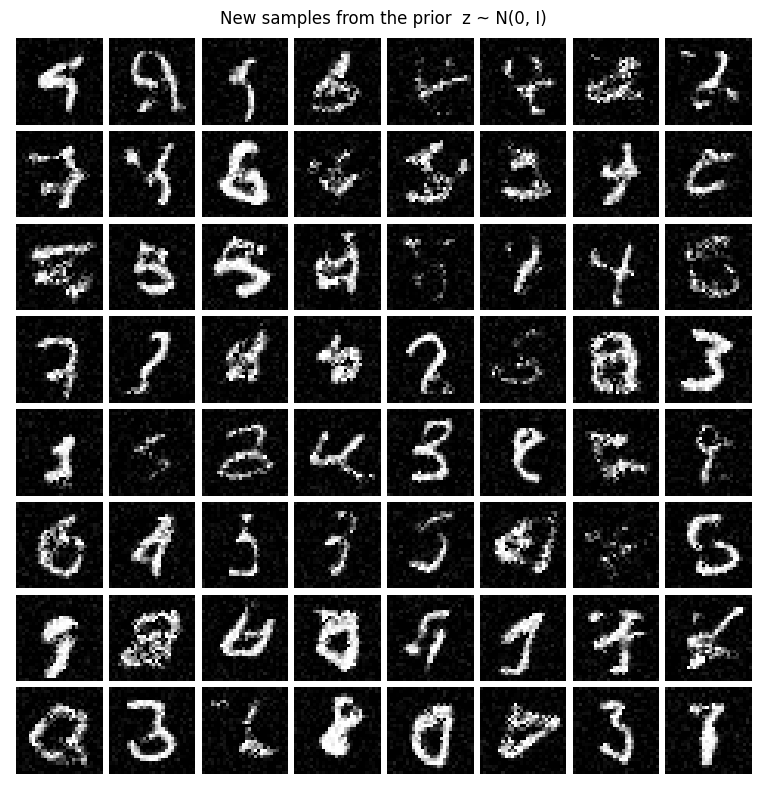

In [37]:
# Task 1d: generate brand-new images by sampling z ~ p(Z) = N(0, I).
@torch.no_grad()
def sample_prior(model, n):
    """Sample z from the prior and then x' ~ p(x|z)."""
    model.eval()
    z = torch.randn(n, K, device=DEVICE)
    mu_x, logvar_x = model.decode(z)
    x_sample = mu_x + torch.exp(0.5 * logvar_x) * torch.randn_like(mu_x)
    return x_sample.clamp(0.0, 1.0)

n_samples = 64
x_gen = sample_prior(vae, n_samples).cpu()
grid = make_grid(x_gen, nrow=8, pad_value=1.0)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).squeeze().numpy(), cmap='gray')
plt.axis('off')
plt.title('New samples from the prior  z ~ N(0, I)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'task1d_prior_samples.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Task 2: Choice of Conditional Data Distributions

## Task 2a: Reflection (Gaussian)

## Task 2b: Beta Distributions

In [ ]:
def beta_log_likelihood(x, alpha_x, beta_x, eps=1e-6):
  x = x.clamp(eps, 1.0 - eps)

  log_prob = (
        torch.lgamma(alpha_x + beta_x)
        - torch.lgamma(alpha_x)
        - torch.lgamma(beta_x)
        + (alpha_x - 1.0) * torch.log(x)
        + (beta_x - 1.0) * torch.log(1.0 - x)
    )

  return log_prob.flatten(start_dim=1).sum(dim=1)

def beta_elbo_terms(x, model_out):
    """Per-sample reconstruction log-likelihood, KL, and ELBO.

    model_out is the tuple returned by BetaVAE.forward:
    (alpha_x, beta_x, mu_z, logvar_z, z).
    """

    alpha_x, beta_x, mu_z, logvar_z, _z = model_out

    log_px_z = beta_log_likelihood(x, alpha_x, beta_x)
    kl = kl_standard_normal(mu_z, logvar_z)

    return log_px_z, kl, log_px_z - kl

In [ ]:
class BetaVAE(nn.Module):
  def __init__(self, k=K):
        super().__init__()
        self.encoder = Encoder(k)
        self.backbone = DecoderBackbone(k)

        self.alpha_head = nn.Conv2d(16, 1, kernel_size=3, padding=1)
        self.beta_head  = nn.Conv2d(16, 1, kernel_size=3, padding=1)

  def encode(self, x):
    return self.encoder(x)

  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

  def decode(self, z):
    h = self.backbone(z)

    alpha_x = F.softplus(self.alpha_head(h)) + 1e-4
    beta_x  = F.softplus(self.beta_head(h)) + 1e-4

    return alpha_x, beta_x

  def forward(self, x):
      mu_z, logvar_z = self.encode(x)
      z = self.reparameterize(mu_z, logvar_z)
      alpha_x, beta_x = self.decode(z)

      return alpha_x, beta_x, mu_z, logvar_z, z


In [ ]:
set_seed()

vae = BetaVAE(K).to(DEVICE)
optimizer = torch.optim.Adam(vae.parameters(), lr=LR)

CKPT_PATH = CKPT_DIR / 'vae_beta.pt'
RETRAIN = True  # set False to skip training and load the saved checkpoint

if RETRAIN or not CKPT_PATH.exists():
    history = fit(vae, train_loader, val_loader, optimizer, CKPT_PATH,elbo_terms=beta_elbo_terms)
else:
    history = load_checkpoint(vae, CKPT_PATH, optimizer)
    print(f'Loaded checkpoint from {CKPT_PATH}')

print(f"Best val ELBO {history['best_val_elbo']:.2f} at epoch {history['best_epoch']}")

Epoch  1 | train ELBO   6267.98 | val ELBO   6531.16  <- best (saved)
Epoch  2 | train ELBO   6678.44 | val ELBO   6785.07  <- best (saved)
Epoch  3 | train ELBO   6834.04 | val ELBO   6887.84  <- best (saved)
Epoch  4 | train ELBO   6901.98 | val ELBO   6960.94  <- best (saved)
Epoch  5 | train ELBO   6965.18 | val ELBO   6998.07  <- best (saved)
Epoch  6 | train ELBO   7004.95 | val ELBO   7057.52  <- best (saved)
Epoch  7 | train ELBO   7031.06 | val ELBO   7094.72  <- best (saved)
Epoch  8 | train ELBO   7031.99 | val ELBO   7106.84  <- best (saved)
Epoch  9 | train ELBO   7075.27 | val ELBO   7151.04  <- best (saved)
Epoch 10 | train ELBO   7035.05 | val ELBO   7146.93
Epoch 11 | train ELBO   7004.94 | val ELBO   7125.38
Epoch 12 | train ELBO   7091.90 | val ELBO   7202.27  <- best (saved)
Epoch 13 | train ELBO   7087.47 | val ELBO   6523.04
Epoch 14 | train ELBO   7019.35 | val ELBO   7175.33
Epoch 15 | train ELBO   7099.32 | val ELBO   7123.23
Epoch 16 | train ELBO   7113.43 | v

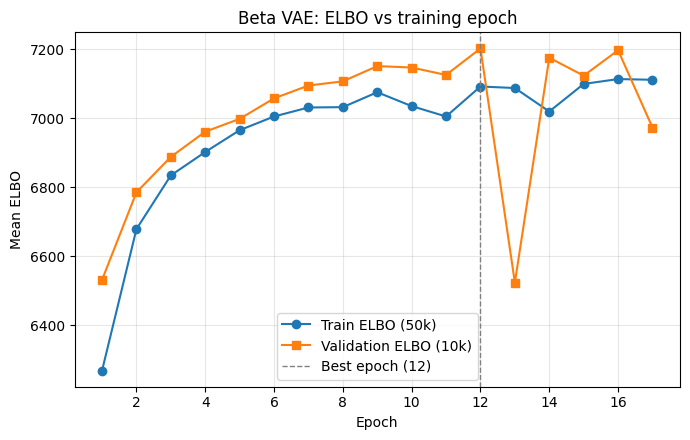

In [ ]:
# ELBO curves: training (50k) vs validation (10k), per epoch (Task 1b).
epochs = range(1, len(history['train_elbo']) + 1)
plt.figure(figsize=(7, 4.5))
plt.plot(epochs, history['train_elbo'], marker='o', label='Train ELBO (50k)')
plt.plot(epochs, history['val_elbo'],   marker='s', label='Validation ELBO (10k)')
plt.axvline(history['best_epoch'], color='gray', ls='--', lw=1,
            label=f"Best epoch ({history['best_epoch']})")
plt.xlabel('Epoch')
plt.ylabel('Mean ELBO')
plt.title('Beta VAE: ELBO vs training epoch')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'task2b_elbo_curves.png', dpi=150, bbox_inches='tight')
plt.show()

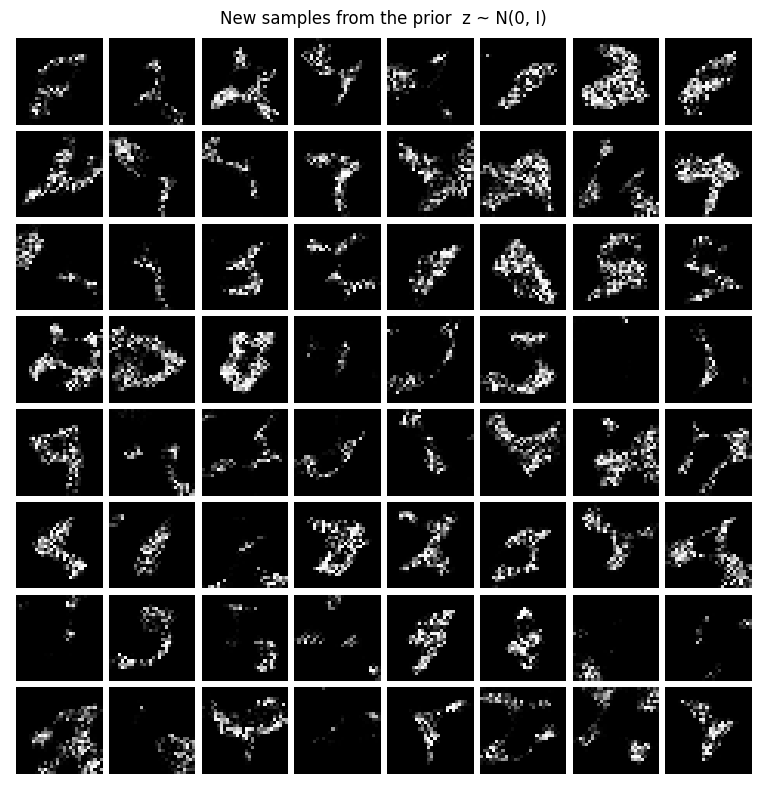

In [ ]:


n_samples = 64

with torch.no_grad():
    vae.eval()

    z = torch.randn(64, K, device=DEVICE)

    alpha_x, beta_x = vae.decode(z)

    x_gen = torch.distributions.Beta(
        alpha_x,
        beta_x
    ).sample()

    x_gen = x_gen.cpu()

grid = make_grid(x_gen, nrow=8, pad_value=1.0)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).squeeze().numpy(), cmap='gray')
plt.axis('off')
plt.title('New samples from the prior  z ~ N(0, I)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'task2b_prior_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 2c: Categorical Distributions

In [ ]:
c=16
def discretize(x,c):
    bins = torch.floor(x * c).long()
    bins = torch.clamp(bins, max=c-1)
    return bins.squeeze(1)


In [ ]:
class catVAE(nn.Module):
  def __init__(self, k=K,C=c):
        super().__init__()
        self.encoder = Encoder(k)
        self.backbone = DecoderBackbone(k)

        self.logits_head = nn.Conv2d(16, C, kernel_size=3, padding=1)

  def encode(self, x):
    return self.encoder(x)

  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

  def decode(self, z):
    h = self.backbone(z)
    logits = self.logits_head(h)

    return logits

  def forward(self, x):
      mu_z, logvar_z = self.encode(x)
      z = self.reparameterize(mu_z, logvar_z)
      logits = self.decode(z)

      return logits, mu_z, logvar_z, z


In [ ]:
def cat_elbo_terms(x, model_out):
    """Per-sample reconstruction log-likelihood, KL, and ELBO.


    """
    C = 16
    targets = discretize(x, C)

    logits, mu_z, logvar_z, z = model_out
    ce = F.cross_entropy(logits, targets,reduction='none')


    log_px_z = -ce.flatten(1).sum(1)
    kl = kl_standard_normal(mu_z, logvar_z)

    return log_px_z, kl, log_px_z - kl

In [ ]:
set_seed()

vae = catVAE(K,C=16).to(DEVICE)
optimizer = torch.optim.Adam(vae.parameters(), lr=LR)

CKPT_PATH = CKPT_DIR / 'vae_cat.pt'
RETRAIN = True  # set False to skip training and load the saved checkpoint

if RETRAIN or not CKPT_PATH.exists():
    history = fit(vae, train_loader, val_loader, optimizer, CKPT_PATH, elbo_terms=cat_elbo_terms)
else:
    history = load_checkpoint(vae, CKPT_PATH, optimizer)
    print(f'Loaded checkpoint from {CKPT_PATH}')

print(f"Best val ELBO {history['best_val_elbo']:.2f} at epoch {history['best_epoch']}")

Epoch  1 | train ELBO   -548.09 | val ELBO   -399.03  <- best (saved)
Epoch  2 | train ELBO   -371.47 | val ELBO   -359.10  <- best (saved)
Epoch  3 | train ELBO   -350.13 | val ELBO   -346.48  <- best (saved)
Epoch  4 | train ELBO   -340.49 | val ELBO   -338.88  <- best (saved)
Epoch  5 | train ELBO   -334.47 | val ELBO   -334.57  <- best (saved)
Epoch  6 | train ELBO   -330.27 | val ELBO   -330.79  <- best (saved)
Epoch  7 | train ELBO   -326.97 | val ELBO   -328.20  <- best (saved)
Epoch  8 | train ELBO   -324.33 | val ELBO   -326.06  <- best (saved)
Epoch  9 | train ELBO   -322.07 | val ELBO   -324.12  <- best (saved)
Epoch 10 | train ELBO   -320.23 | val ELBO   -323.17  <- best (saved)
Epoch 11 | train ELBO   -318.56 | val ELBO   -322.85  <- best (saved)
Epoch 12 | train ELBO   -316.88 | val ELBO   -320.61  <- best (saved)
Epoch 13 | train ELBO   -315.69 | val ELBO   -318.66  <- best (saved)
Epoch 14 | train ELBO   -314.35 | val ELBO   -318.06  <- best (saved)
Epoch 15 | train ELB

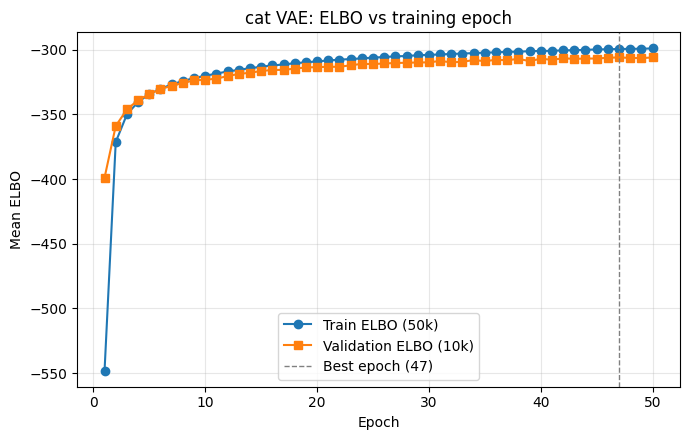

In [ ]:
epochs = range(1, len(history['train_elbo']) + 1)
plt.figure(figsize=(7, 4.5))
plt.plot(epochs, history['train_elbo'], marker='o', label='Train ELBO (50k)')
plt.plot(epochs, history['val_elbo'],   marker='s', label='Validation ELBO (10k)')
plt.axvline(history['best_epoch'], color='gray', ls='--', lw=1,
            label=f"Best epoch ({history['best_epoch']})")
plt.xlabel('Epoch')
plt.ylabel('Mean ELBO')
plt.title('cat VAE: ELBO vs training epoch')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'task2c_elbo_curves.png', dpi=150, bbox_inches='tight')
plt.show()

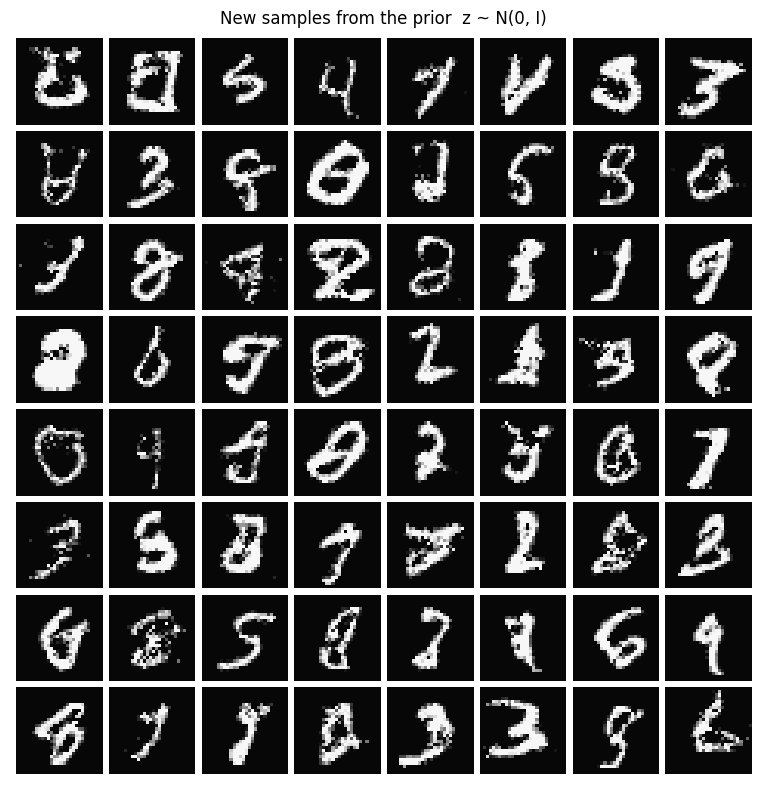

In [ ]:
with torch.no_grad():
    vae.eval()

    z = torch.randn(n_samples, K, device=DEVICE)

    logits = vae.decode(z)  # (B, C, 28, 28)

    probs = torch.softmax(logits, dim=1)

    bins = torch.distributions.Categorical(
        probs.permute(0, 2, 3, 1)
    ).sample()  # (B, 28, 28)

    # Convert bin assignments back to pixel intensities using bin midpoints
    x_gen = ((bins.float() + 0.5) / c).unsqueeze(1)



    x_gen = x_gen.cpu()

grid = make_grid(x_gen, nrow=8, pad_value=1.0)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).squeeze().numpy(), cmap='gray')
plt.axis('off')
plt.title('New samples from the prior  z ~ N(0, I)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'task2b_prior_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 2d: Bernoulli Distributions

In [ ]:
class bernoulliVAE(nn.Module):
  def __init__(self, k=K):
        super().__init__()
        self.encoder = Encoder(k)
        self.backbone = DecoderBackbone(k)

        self.pi_head = nn.Conv2d(16, 1, kernel_size=3, padding=1)

  def encode(self, x):
    return self.encoder(x)

  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

  def decode(self, z):
    h = self.backbone(z)
    pi_x = torch.sigmoid(self.pi_head(h))

    return pi_x

  def forward(self, x):
      mu_z, logvar_z = self.encode(x)
      z = self.reparameterize(mu_z, logvar_z)
      pi_x = self.decode(z)

      return pi_x, mu_z, logvar_z, z


In [ ]:
def bernoulli_log_likelihood(x, pi_x, eps=1e-6):

    pi_x = pi_x.clamp(eps, 1-eps)

    log_prob = (
        x * torch.log(pi_x)
        + (1 - x) * torch.log(1 - pi_x)
    )

    return log_prob.flatten(1).sum(1)

In [ ]:
def bernoulli_elbo_terms(x, model_out):

    pi_x, mu_z, logvar_z, _z = model_out

    log_px_z = bernoulli_log_likelihood(x, pi_x)

    kl = kl_standard_normal(mu_z, logvar_z)

    return log_px_z, kl, log_px_z - kl

In [ ]:
set_seed()

vae = bernoulliVAE(K).to(DEVICE)
optimizer = torch.optim.Adam(vae.parameters(), lr=LR)

CKPT_PATH = CKPT_DIR / 'vae_bernoulli.pt'
RETRAIN = True  # set False to skip training and load the saved checkpoint

if RETRAIN or not CKPT_PATH.exists():
    history = fit(vae, train_loader, val_loader, optimizer, CKPT_PATH, elbo_terms=bernoulli_elbo_terms)
else:
    history = load_checkpoint(vae, CKPT_PATH, optimizer)
    print(f'Loaded checkpoint from {CKPT_PATH}')

print(f"Best val ELBO {history['best_val_elbo']:.2f} at epoch {history['best_epoch']}")

Epoch  1 | train ELBO   -187.85 | val ELBO   -122.38  <- best (saved)
Epoch  2 | train ELBO   -114.81 | val ELBO   -110.48  <- best (saved)
Epoch  3 | train ELBO   -108.67 | val ELBO   -107.50  <- best (saved)
Epoch  4 | train ELBO   -106.26 | val ELBO   -105.50  <- best (saved)
Epoch  5 | train ELBO   -104.77 | val ELBO   -104.49  <- best (saved)
Epoch  6 | train ELBO   -103.72 | val ELBO   -103.62  <- best (saved)
Epoch  7 | train ELBO   -102.98 | val ELBO   -103.20  <- best (saved)
Epoch  8 | train ELBO   -102.35 | val ELBO   -102.59  <- best (saved)
Epoch  9 | train ELBO   -101.87 | val ELBO   -102.68
Epoch 10 | train ELBO   -101.45 | val ELBO   -102.36  <- best (saved)
Epoch 11 | train ELBO   -101.09 | val ELBO   -101.64  <- best (saved)
Epoch 12 | train ELBO   -100.80 | val ELBO   -101.31  <- best (saved)
Epoch 13 | train ELBO   -100.53 | val ELBO   -101.03  <- best (saved)
Epoch 14 | train ELBO   -100.21 | val ELBO   -101.10
Epoch 15 | train ELBO   -100.01 | val ELBO   -100.60  

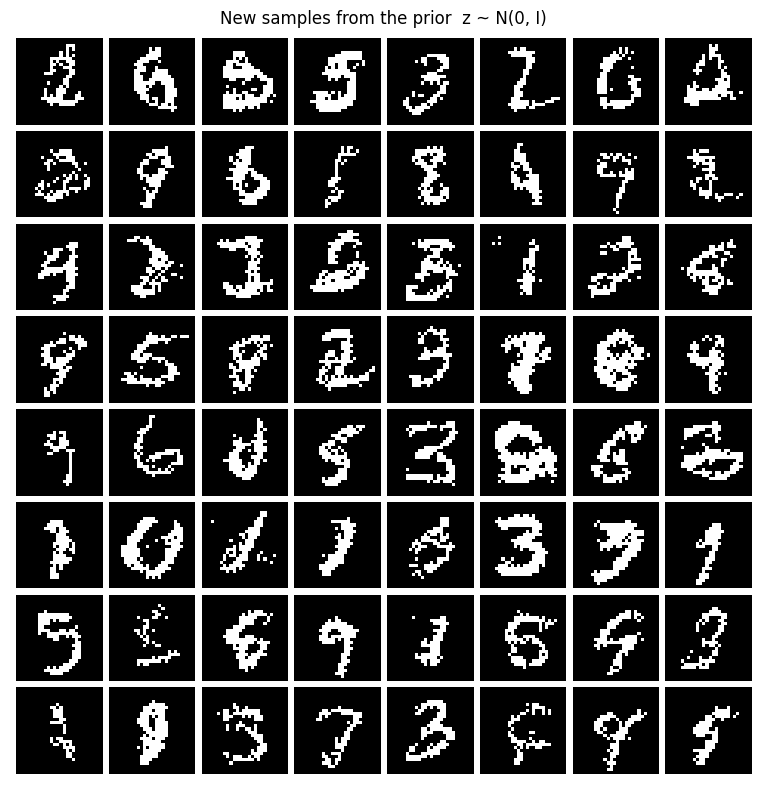

In [ ]:
n_samples = 64
with torch.no_grad():
    vae.eval()

    z = torch.randn(64, K, device=DEVICE)

    pi_x = vae.decode(z)

    x_gen = torch.bernoulli(pi_x)

    x_gen = x_gen.cpu()

grid = make_grid(x_gen, nrow=8, pad_value=1.0)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).squeeze().numpy(), cmap='gray')
plt.axis('off')
plt.title('New samples from the prior  z ~ N(0, I)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'task2b_prior_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 2e: Reflection

---
# Task 3: Investigate the Latent Space

## Task 3a: Visualizing the Latent Space (K = 2)

Epoch  1 | train ELBO    505.54 | val ELBO    793.39  <- best (saved)
Epoch  2 | train ELBO    813.23 | val ELBO    832.99  <- best (saved)
Epoch  3 | train ELBO    837.44 | val ELBO    849.84  <- best (saved)
Epoch  4 | train ELBO    852.00 | val ELBO    862.55  <- best (saved)
Epoch  5 | train ELBO    860.46 | val ELBO    868.35  <- best (saved)
Epoch  6 | train ELBO    867.47 | val ELBO    875.61  <- best (saved)
Epoch  7 | train ELBO    872.12 | val ELBO    881.57  <- best (saved)
Epoch  8 | train ELBO    876.13 | val ELBO    883.50  <- best (saved)
Epoch  9 | train ELBO    879.12 | val ELBO    886.67  <- best (saved)
Epoch 10 | train ELBO    882.12 | val ELBO    889.60  <- best (saved)
Epoch 11 | train ELBO    884.99 | val ELBO    889.16
Epoch 12 | train ELBO    887.15 | val ELBO    891.87  <- best (saved)
Epoch 13 | train ELBO    889.94 | val ELBO    893.94  <- best (saved)
Epoch 14 | train ELBO    892.22 | val ELBO    896.21  <- best (saved)
Epoch 15 | train ELBO    894.41 | val

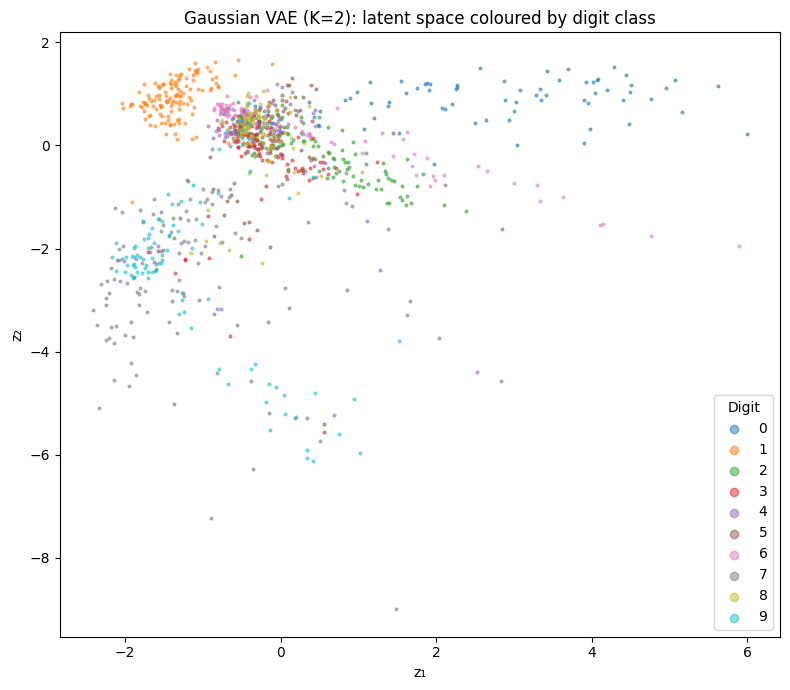

In [49]:
# ---- Task 3a: Train a K=2 Gaussian VAE and visualise its latent space ----

set_seed()

test_1k = Subset(test_set, range(1000))
test_1k_loader = DataLoader(test_1k, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=2, pin_memory=(DEVICE.type == 'cuda'))

K2 = 2
vae2d = GaussianVAE(K2).to(DEVICE)
opt2d = torch.optim.Adam(vae2d.parameters(), lr=LR)
CKPT_2D = CKPT_DIR / 'vae_gaussian_k2.pt'
RETRAIN_2D = True

if RETRAIN_2D or not CKPT_2D.exists():
    history2d = fit(vae2d, train_loader, val_loader, opt2d, CKPT_2D)
else:
    history2d = load_checkpoint(vae2d, CKPT_2D, opt2d)
    print(f'Loaded checkpoint from {CKPT_2D}')

print(f"Best val ELBO {history2d['best_val_elbo']:.2f} at epoch {history2d['best_epoch']}")


@torch.no_grad()
def encode_dataset(model, loader):
    """Encode a full dataset loader; returns (mu_z array, label array)."""
    model.eval()
    mus, labels = [], []
    for x, y in loader:
        mu_z, _ = model.encode(x.to(DEVICE))
        mus.append(mu_z.cpu())
        labels.append(y)
    return torch.cat(mus).numpy(), torch.cat(labels).numpy()


mu_2d, lbl_2d = encode_dataset(vae2d, test_1k_loader)

cmap10 = plt.get_cmap('tab10')
fig, ax = plt.subplots(figsize=(8, 7))
for digit in range(10):
    mask = lbl_2d == digit
    ax.scatter(mu_2d[mask, 0], mu_2d[mask, 1], s=4, alpha=0.5,
               color=cmap10(digit), label=str(digit))
ax.legend(title='Digit', markerscale=3, loc='best')
ax.set_xlabel('z₁')
ax.set_ylabel('z₂')
ax.set_title('Gaussian VAE (K=2): latent space coloured by digit class')
plt.tight_layout()
plt.savefig(FIG_DIR / 'task3a_latent_2d.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 3b: Visualizing the Latent Space, using PCA (K >= 10)

Explained variance ratio (PC1, PC2): 0.171, 0.120  (total: 0.291)


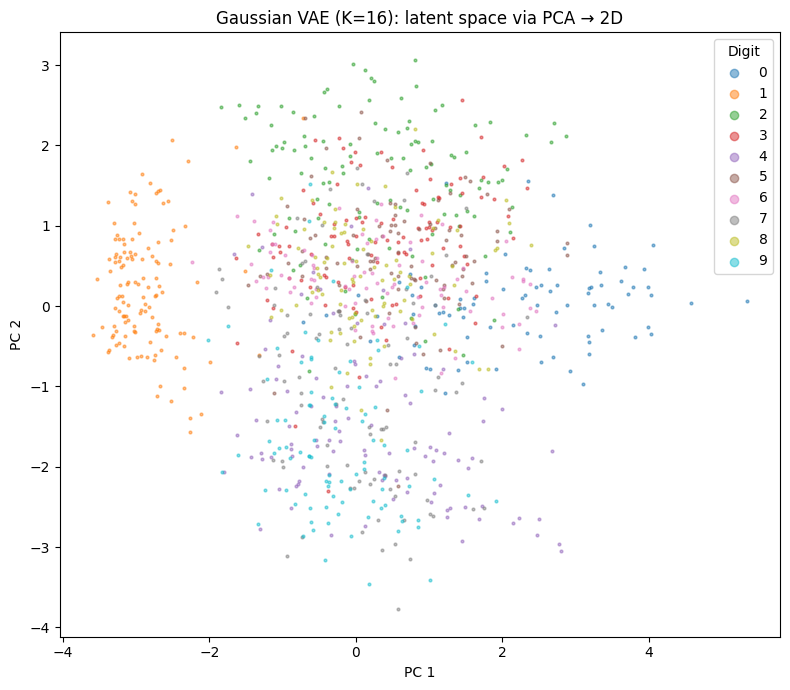

In [45]:
# ---- Task 3b: Encode with K=16 VAE and project to 2D via PCA ----

from sklearn.decomposition import PCA

# Reload the K=16 Gaussian VAE trained in Task 1
vae_k16 = GaussianVAE(K).to(DEVICE)
load_checkpoint(vae_k16, CKPT_DIR / 'vae_gaussian.pt')

mu_k16, lbl_k16 = encode_dataset(vae_k16, test_1k_loader)

pca = PCA(n_components=2)
mu_pca = pca.fit_transform(mu_k16)
print(f'Explained variance ratio (PC1, PC2): '
      f'{pca.explained_variance_ratio_[0]:.3f}, {pca.explained_variance_ratio_[1]:.3f}  '
      f'(total: {pca.explained_variance_ratio_.sum():.3f})')

fig, ax = plt.subplots(figsize=(8, 7))
for digit in range(10):
    mask = lbl_k16 == digit
    ax.scatter(mu_pca[mask, 0], mu_pca[mask, 1], s=4, alpha=0.5,
               color=cmap10(digit), label=str(digit))
ax.legend(title='Digit', markerscale=3, loc='best')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_title(f'Gaussian VAE (K={K}): latent space via PCA → 2D')
plt.tight_layout()
plt.savefig(FIG_DIR / 'task3b_latent_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 3c: Interpolation in the Latent Space

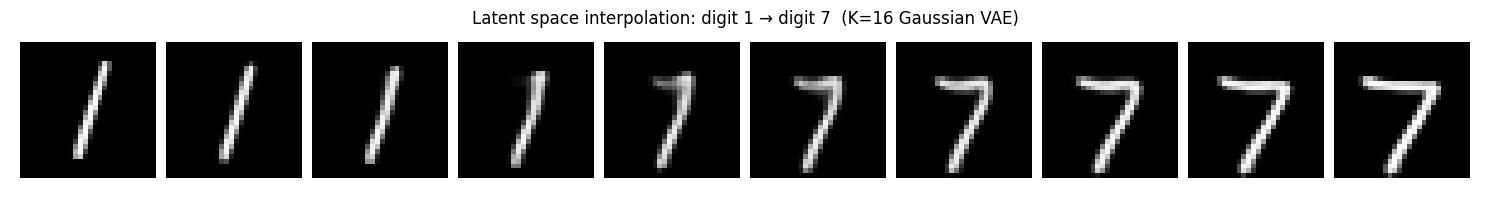

In [50]:
# ---- Task 3c: Interpolate between two test images in the latent space ----

N_STEPS = 10


@torch.no_grad()
def interpolate_latent(model, x1, x2, n_steps=N_STEPS):
    """Linearly interpolate between the encoded means of x1 and x2."""
    model.eval()
    mu1, _ = model.encode(x1.unsqueeze(0).to(DEVICE))
    mu2, _ = model.encode(x2.unsqueeze(0).to(DEVICE))
    alphas = torch.linspace(0, 1, n_steps, device=DEVICE)
    imgs = []
    for a in alphas:
        z = (1 - a) * mu1 + a * mu2
        mu_x, _ = model.decode(z)
        imgs.append(mu_x.squeeze(0).cpu())
    return imgs


def find_first_digit(dataset, digit):
    for img, lbl in dataset:
        if lbl == digit:
            return img
    raise ValueError(f'digit {digit} not found')


x_src = find_first_digit(test_1k, 1)
x_tgt = find_first_digit(test_1k, 7)

interp_imgs = interpolate_latent(vae_k16, x_src, x_tgt)
grid = make_grid(interp_imgs, nrow=N_STEPS, pad_value=1.0)

fig, ax = plt.subplots(figsize=(N_STEPS * 1.5, 2))
ax.imshow(grid.permute(1, 2, 0).squeeze().numpy(), cmap='gray')
ax.axis('off')
ax.set_title('Latent space interpolation: digit 1 → digit 7  (K=16 Gaussian VAE)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'task3c_interpolation.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Task 4: Inference Without the Encoder

## Task 4a: Reconstruction without the Encoder

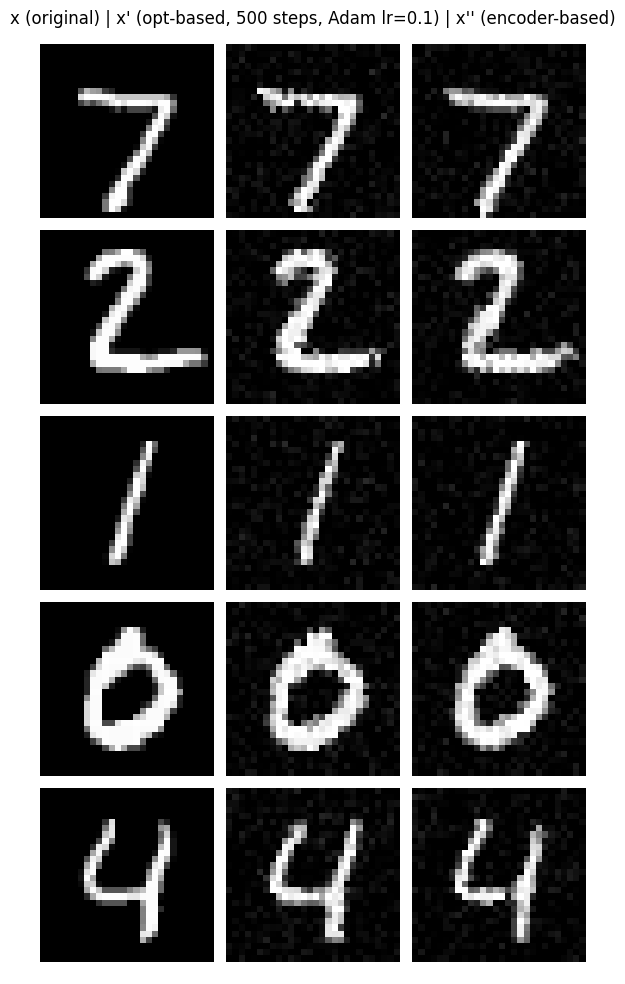

In [52]:
# ---- Task 4a: Reconstruction without the Encoder ----
# Stopping criterion: fixed 500 Adam steps (lr=0.1) per image.
# This is sufficient for convergence on 28×28 MNIST images with K=16 latent dims.

N_OPT_STEPS = 500
OPT_LR      = 0.1
N_DISPLAY   = 5   # number of test images shown in the grid


def optimize_psi(model, x, n_steps=N_OPT_STEPS, lr=OPT_LR):
    """Optimize variational parameters Ψ=(μ_Ψ, logvar_Ψ) for a single image.
    Decoder weights are frozen; only Ψ receives gradients."""
    model.eval()
    x_dev      = x.unsqueeze(0).to(DEVICE)
    mu_psi     = torch.zeros(1, K, device=DEVICE, requires_grad=True)
    logvar_psi = torch.zeros(1, K, device=DEVICE, requires_grad=True)
    opt = torch.optim.Adam([mu_psi, logvar_psi], lr=lr)
    for _ in range(n_steps):
        opt.zero_grad()
        z = mu_psi + torch.exp(0.5 * logvar_psi) * torch.randn(1, K, device=DEVICE)
        mu_x, logvar_x = model.decode(z)
        elbo = gaussian_log_likelihood(x_dev, mu_x, logvar_x) - kl_standard_normal(mu_psi, logvar_psi)
        (-elbo.mean()).backward()
        opt.step()
    return mu_psi.detach(), logvar_psi.detach()


@torch.no_grad()
def sample_recon_opt(model, mu_psi, logvar_psi):
    """Sample x' from p(x|z) where z ~ q(z|Ψ*)."""
    z = mu_psi + torch.exp(0.5 * logvar_psi) * torch.randn_like(mu_psi)
    mu_x, logvar_x = model.decode(z)
    return (mu_x + torch.exp(0.5 * logvar_x) * torch.randn_like(mu_x)).clamp(0, 1).squeeze(0).cpu()


@torch.no_grad()
def encoder_reconstruct(model, x):
    """Task-1d-style reconstruction: encode → sample z → decode → sample x''."""
    model.eval()
    mu_z, logvar_z = model.encode(x.unsqueeze(0).to(DEVICE))
    z = model.reparameterize(mu_z, logvar_z)
    mu_x, logvar_x = model.decode(z)
    return (mu_x + torch.exp(0.5 * logvar_x) * torch.randn_like(mu_x)).clamp(0, 1).squeeze(0).cpu()


all_imgs_4a = []
for i in range(N_DISPLAY):
    x, _ = test_1k[i]
    mu_psi, logvar_psi = optimize_psi(vae_k16, x)
    x_prime  = sample_recon_opt(vae_k16, mu_psi, logvar_psi)
    x_double = encoder_reconstruct(vae_k16, x)
    all_imgs_4a.extend([x, x_prime, x_double])

grid = make_grid(all_imgs_4a, nrow=3, pad_value=1.0)
fig, ax = plt.subplots(figsize=(6, N_DISPLAY * 2))
ax.imshow(grid.permute(1, 2, 0).squeeze().numpy(), cmap='gray')
ax.axis('off')
ax.set_title(f"x (original) | x' (opt-based, {N_OPT_STEPS} steps, Adam lr={OPT_LR}) | x'' (encoder-based)")
plt.tight_layout()
plt.savefig(FIG_DIR / 'task4a_reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 4b: Image Completion

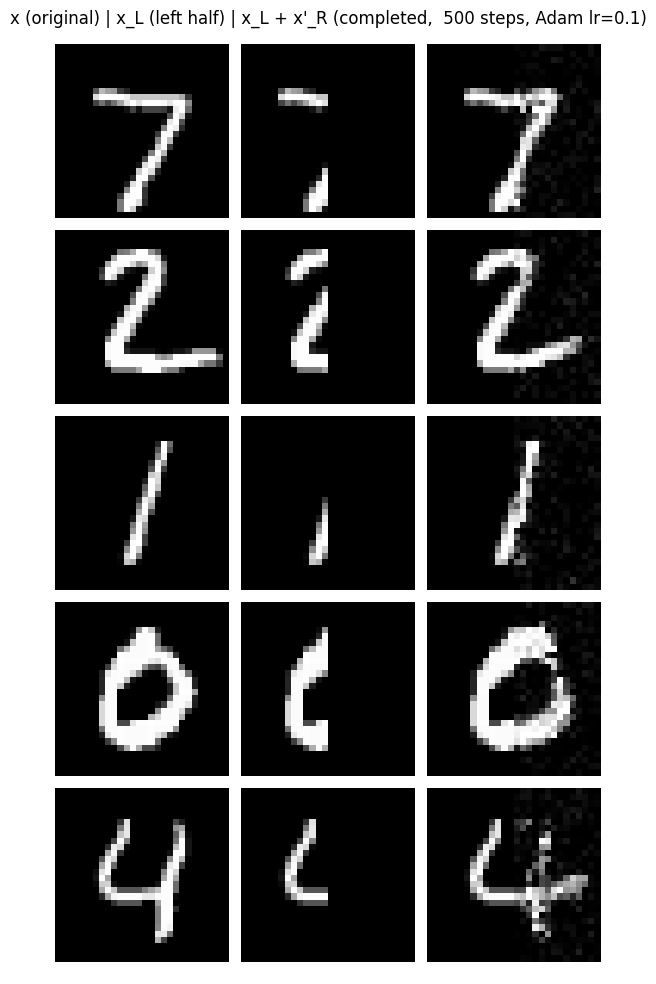

In [53]:
# ---- Task 4b: Image Completion ----

def optimize_psi_partial(model, x, n_steps=N_OPT_STEPS, lr=OPT_LR):
    """Optimize Ψ using ELBO computed only over the left half of x (columns 0:14)."""
    model.eval()
    x_left = x.unsqueeze(0).to(DEVICE)[:, :, :, :14]
    mu_psi     = torch.zeros(1, K, device=DEVICE, requires_grad=True)
    logvar_psi = torch.zeros(1, K, device=DEVICE, requires_grad=True)
    opt = torch.optim.Adam([mu_psi, logvar_psi], lr=lr)
    for _ in range(n_steps):
        opt.zero_grad()
        z = mu_psi + torch.exp(0.5 * logvar_psi) * torch.randn(1, K, device=DEVICE)
        mu_x, logvar_x = model.decode(z)
        log_px = gaussian_log_likelihood(x_left, mu_x[:, :, :, :14], logvar_x[:, :, :, :14])
        kl = kl_standard_normal(mu_psi, logvar_psi)
        (-(log_px - kl).mean()).backward()
        opt.step()
    return mu_psi.detach(), logvar_psi.detach()


all_imgs_4b = []
for i in range(N_DISPLAY):
    x, _ = test_1k[i]
    mu_psi, logvar_psi = optimize_psi_partial(vae_k16, x)
    with torch.no_grad():
        z = mu_psi + torch.exp(0.5 * logvar_psi) * torch.randn_like(mu_psi)
        mu_x, logvar_x = vae_k16.decode(z)
        x_pred = (mu_x + torch.exp(0.5 * logvar_x) * torch.randn_like(mu_x)).clamp(0, 1).squeeze(0).cpu()

    x_masked    = x.clone(); x_masked[:, :, 14:]    = 0.0
    x_completed = x.clone(); x_completed[:, :, 14:] = x_pred[:, :, 14:]
    all_imgs_4b.extend([x, x_masked, x_completed])

grid = make_grid(all_imgs_4b, nrow=3, pad_value=1.0)
fig, ax = plt.subplots(figsize=(6, N_DISPLAY * 2))
ax.imshow(grid.permute(1, 2, 0).squeeze().numpy(), cmap='gray')
ax.axis('off')
ax.set_title(f"x (original) | x_L (left half) | x_L + x'_R (completed,  {N_OPT_STEPS} steps, Adam lr={OPT_LR})")
plt.tight_layout()
plt.savefig(FIG_DIR / 'task4b_completion.png', dpi=150, bbox_inches='tight')
plt.show()